# 3. Modelos Clásicos de Machine Learning

En este notebook aprenderás y compararás los modelos clásicos de Machine Learning: Árboles de Decisión, Random Forest, SVM y KNN, usando el dataset Digits de scikit-learn.

## Objetivo
- Comprender el funcionamiento y diferencias entre modelos clásicos de ML.
- Comparar desempeño y visualización de resultados.
- Aprender trucos y mejores prácticas para cada modelo.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01 (Intro ML)](./01_intro_machine_learning.ipynb) y [02 (Preprocesamiento)](./02_preprocesamiento_visualizacion.ipynb).

- Conceptos de train/test split, escalado, y métricas de clasificación.

## 1. Introducción teórica

Los modelos clásicos de Machine Learning son algoritmos fundamentales que permiten resolver tareas de clasificación y regresión. En este notebook nos enfocaremos en:

| Modelo | Tipo | Ventaja principal | Desventaja principal |
|--------|------|-------------------|---------------------|
| **Árbol de Decisión** | No lineal | Fácil de interpretar, no requiere escalado | Tiende a sobreajustar |
| **Random Forest** | Ensamble | Robusto, reduce varianza | Menos interpretable, más lento |
| **SVM** | Lineal/No lineal | Potente en alta dimensión, kernels flexibles | Lento en datasets grandes, sensible a la escala |
| **KNN** | Basado en instancias | Simple, sin entrenamiento | Lento en predicción, sensible a la escala y dimensión |

### Consideraciones clave
- Cada modelo tiene ventajas y desventajas según el tipo de datos y el problema.
- Es importante comparar su desempeño y entender cuándo usar cada uno.
- Analizaremos hiperparámetros, visualizaremos resultados y daremos recomendaciones prácticas.

## 2. Importación de librerías

In [12]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
%matplotlib inline

## 3. Carga y exploración del dataset

Usaremos el dataset Digits de scikit-learn, ideal para comparar modelos de clasificación multiclase. Es un dataset de imágenes de dígitos escritos a mano (8x8 píxeles).

Shape de X: (1797, 64), Shape de y: (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]


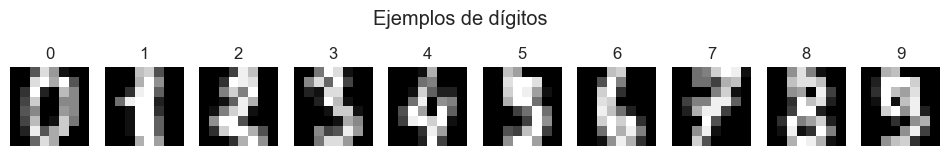

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
print(f"Clases: {digits.target_names}")

# Visualizar algunos dígitos
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"{digits.target[i]}")
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos')
plt.show()

## 4. Preprocesamiento de datos

- Estandarizaremos las características para modelos sensibles a la escala (SVM, KNN).
- Dividiremos con `stratify` para mantener el balance de clases.

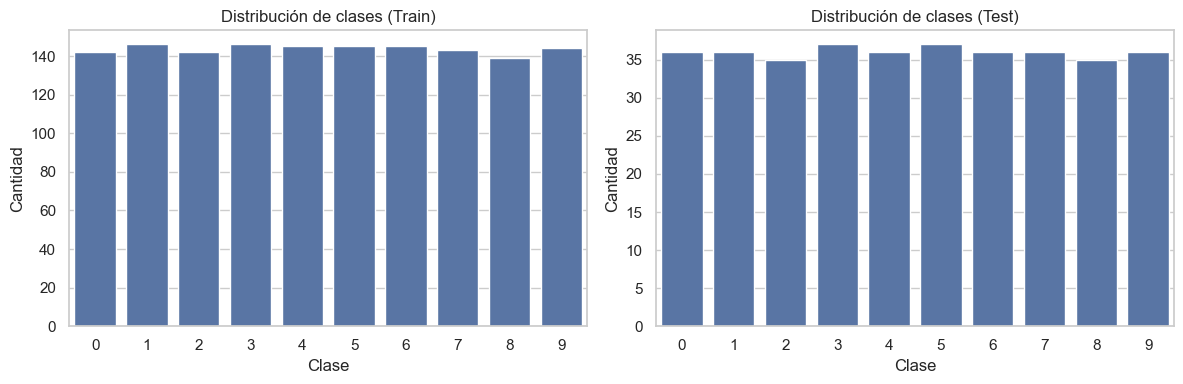

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data_y, title in zip(axes, [y_train, y_test], ['Train', 'Test']):
    sns.countplot(x=data_y, ax=ax)
    ax.set_title(f'Distribución de clases ({title})')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

## 5. Entrenamiento y comparación de modelos

Entrenaremos y compararemos los 4 modelos clásicos, mostrando métricas y la matriz de confusión para cada uno.


  Árbol de Decisión — Accuracy: 0.8167


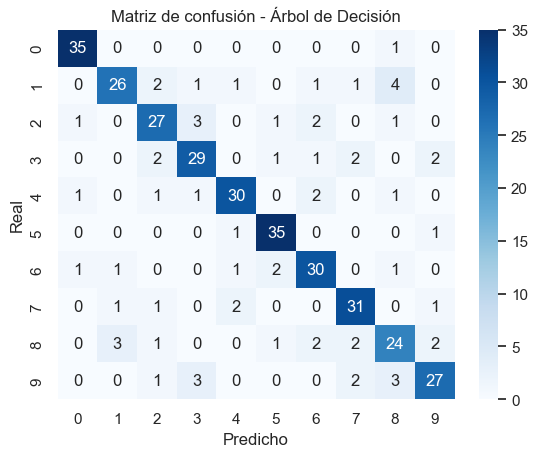

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.77      0.77      0.77        35
           3       0.78      0.78      0.78        37
           4       0.86      0.83      0.85        36
           5       0.88      0.95      0.91        37
           6       0.79      0.83      0.81        36
           7       0.82      0.86      0.84        36
           8       0.69      0.69      0.69        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.81       360
weighted avg       0.82      0.82      0.82       360


  Random Forest — Accuracy: 0.9639


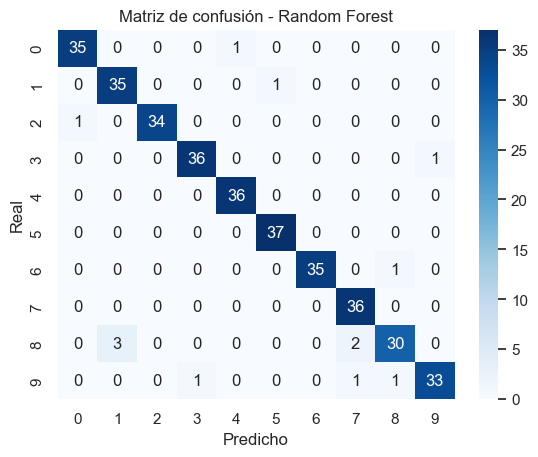

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


  SVM — Accuracy: 0.9750


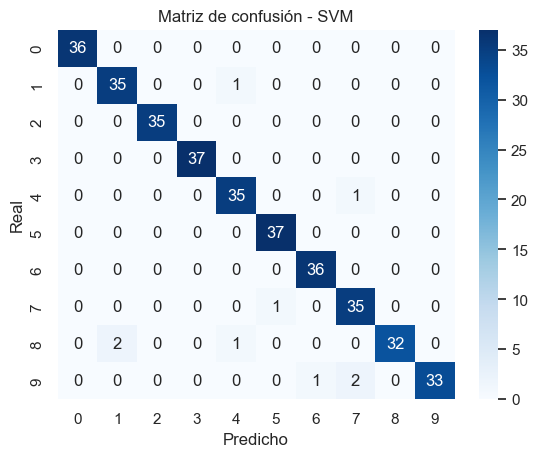

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360


  KNN — Accuracy: 0.9639


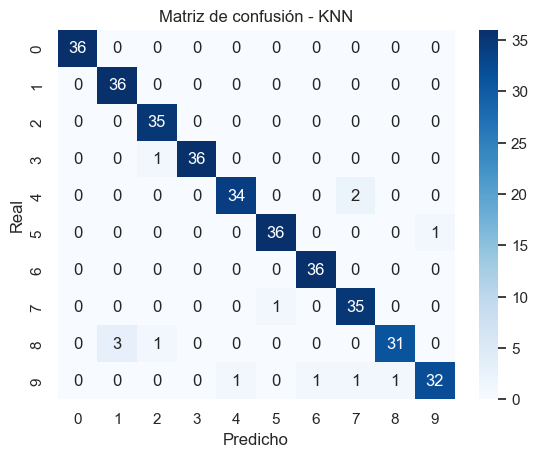

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [4]:
models = {
    'Árbol de Decisión': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {'accuracy': acc, 'confusion_matrix': cm, 'report': cr, 'model': model}
    print(f"\n{'='*50}")
    print(f"  {name} — Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_test, y_pred))

## 6. Comparación de desempeño

Visualizaremos la precisión de cada modelo para facilitar la comparación.

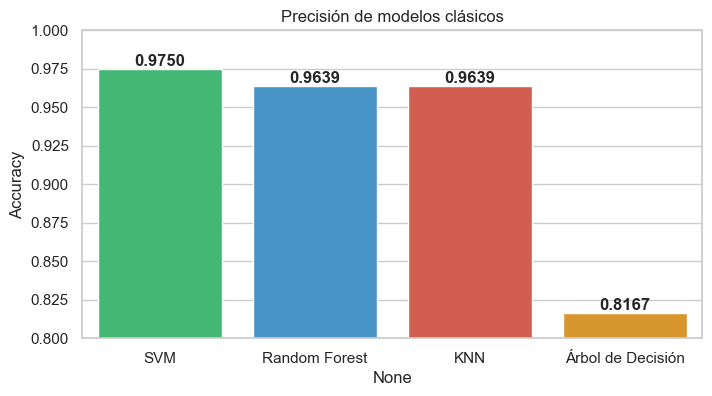

,accuracy
SVM,0.975000
Random Forest,0.963889
KNN,0.963889
Árbol de Decisión,0.816667


In [5]:
df_results = pd.DataFrame({name: [res['accuracy']] for name, res in results.items()})
df_results = df_results.T.rename(columns={0: 'accuracy'})
df_results = df_results.sort_values('accuracy', ascending=False)

plt.figure(figsize=(8,4))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
sns.barplot(x=df_results.index, y='accuracy', data=df_results, palette=colors[:len(df_results)])
plt.title('Precisión de modelos clásicos')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
for i, v in enumerate(df_results['accuracy']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

df_results

## 7. Ajuste de hiperparámetros

Usaremos `GridSearchCV` para encontrar los mejores hiperparámetros de Random Forest y SVM.

In [6]:
# Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf, cv=3, n_jobs=-1)
gs_rf.fit(X_train_scaled, y_train)
print("Mejores parámetros RF:", gs_rf.best_params_)
print("Mejor accuracy RF (CV):", f"{gs_rf.best_score_:.4f}")

# SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
gs_svm = GridSearchCV(SVC(probability=True, random_state=SEED), param_grid_svm, cv=3, n_jobs=-1)
gs_svm.fit(X_train_scaled, y_train)
print("\nMejores parámetros SVM:", gs_svm.best_params_)
print("Mejor accuracy SVM (CV):", f"{gs_svm.best_score_:.4f}")

Mejores parámetros RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mejor accuracy RF (CV): 0.9708

Mejores parámetros SVM: {'C': 10, 'kernel': 'rbf'}
Mejor accuracy SVM (CV): 0.9805


### Recomendaciones prácticas por modelo

| Modelo | Hiperparámetros clave | Consejo |
|--------|----------------------|----------|
| **Árbol de Decisión** | `max_depth`, `min_samples_split` | Limita la profundidad para evitar sobreajuste |
| **Random Forest** | `n_estimators`, `max_features`, `max_depth` | Más árboles → más robusto, pero más lento |
| **SVM** | `C`, `kernel`, `gamma` | Escala los datos; prueba kernel `rbf` primero |
| **KNN** | `n_neighbors`, `weights`, `metric` | Escala los datos; usa validación cruzada para elegir K |

**Truco general:** Siempre valida con cross-validation y analiza la matriz de confusión para errores frecuentes.

## 8. Visualización de fronteras de decisión (2D)

Para ilustrar cómo separan las clases los modelos, reduciremos a 2D con PCA y graficaremos las fronteras.

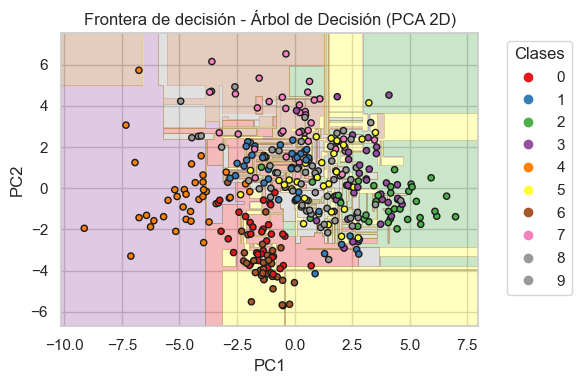

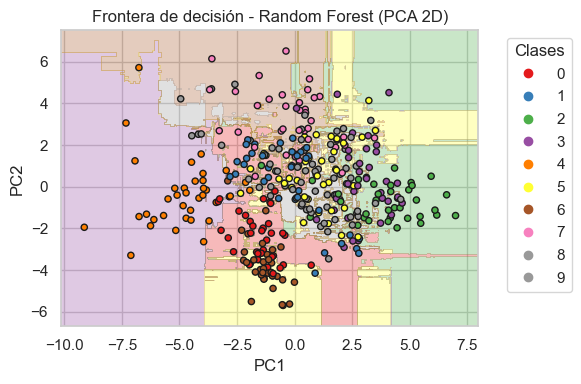

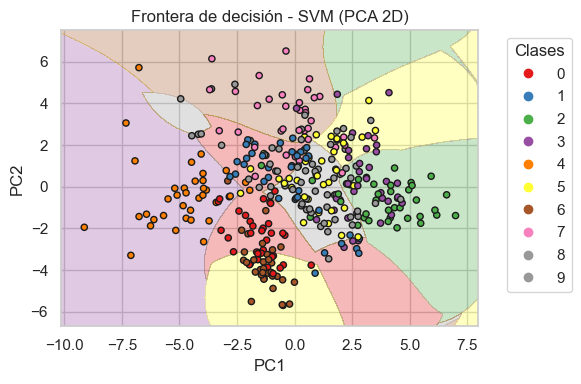

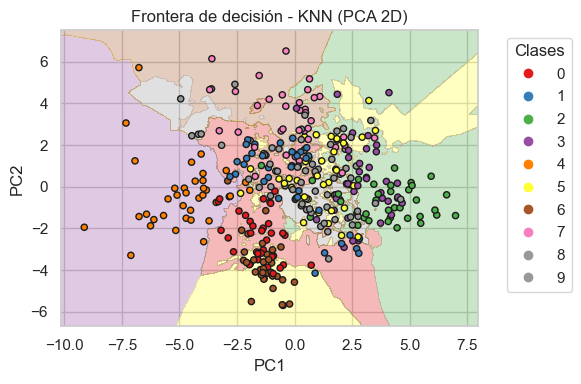

In [9]:
def plot_decision_boundaries_2d(X, y, model, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k', s=20)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(*scatter.legend_elements(), title="Clases", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# PCA a 2 componentes
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar modelos en 2D y graficar
for name, model in models.items():
    model_2d = model.__class__(**model.get_params())
    model_2d.fit(X_train_pca, y_train)
    plot_decision_boundaries_2d(X_test_pca, y_test, model_2d, f"Frontera de decisión - {name} (PCA 2D)")

## 9. Discusión y Conclusiones

- Comparamos 4 modelos clásicos de ML en un problema real de clasificación multiclase.
- SVM y Random Forest suelen dar los mejores resultados en este tipo de datos.
- El Árbol de Decisión es el más interpretable pero el menos preciso.
- KNN es simple pero costoso en predicción para datasets grandes.
- El escalado afecta principalmente a SVM y KNN.

**¿Cuándo usar cada modelo?**
- **Interpretabilidad requerida** → Árbol de Decisión
- **Mejor accuracy general** → Random Forest o SVM
- **Datasets pequeños, prototipado rápido** → KNN

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia el dataset a `load_wine()` y repite la comparación. ¿Qué modelo gana?

2. **Ejercicio 2:** Visualiza el árbol de decisión entrenado con `plot_tree`. Limita `max_depth=3` para que sea legible. ¿Qué variables usa para dividir?

3. **Ejercicio 3:** Experimenta con diferentes valores de `n_neighbors` en KNN (K=1, 3, 5, 7, 15). Grafica accuracy vs K.

4. **Ejercicio 4 (Avanzado):** Implementa un ensamble de votación (`VotingClassifier`) combinando los 4 modelos. ¿Mejora el accuracy?

# Resolución de Ejercicios Propuestos

En esta sección final, pondremos a prueba la capacidad de generalización de los algoritmos clásicos y exploraremos técnicas de ensamble:

1.  **Ejercicio 1: Comparación en un nuevo dominio (`load_wine`).** Evaluaremos cómo se comportan los 4 modelos (Regresión Logística, KNN, Árboles y SVM) en un dataset diferente para determinar cuál es el más versátil.
2.  **Ejercicio 4 (Avanzado): Ensamble por Votación.** Crearemos un `VotingClassifier` que combine la "sabiduría" de los 4 modelos para intentar obtener una predicción final más precisa y estable.

## Ejercicio 1: Evaluación con el Dataset Wine

Cambiamos el contexto de dígitos escritos a mano a la clasificación química de vinos. Este dataset tiene 13 variables y 3 clases. Repetiremos el flujo completo de preprocesamiento y entrenamiento para los 4 modelos.

In [11]:
# 1. Cargar el nuevo dataset
wine = load_wine()
X_w, y_w = wine.data, wine.target

# 2. División Datos (80% train, 20% test)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=SEED, stratify=y_w
)

# 3. Escalado (Fundamental para KNN, Logistic y SVM)
scaler_w = StandardScaler()
X_train_w = scaler_w.fit_transform(X_train_w)
X_test_w = scaler_w.transform(X_test_w)

# 4. Definición de modelos (Usando hiperparámetros base)
modelos_vinitos = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=SEED)
}

# 5. Entrenamiento y Evaluación
print("Resultados Dataset Wine:")
for nombre, modelo in modelos_vinitos.items():
    modelo.fit(X_train_w, y_train_w)
    y_pred_w = modelo.predict(X_test_w)
    acc_w = accuracy_score(y_test_w, y_pred_w)
    print(f"- {nombre}: {acc_w:.4f}")

Resultados Dataset Wine:
- Logistic Regression: 0.9722
- KNN (K=5): 0.9722
- Decision Tree: 0.9444
- SVM (RBF): 0.9722


## Ejercicio 4: Ensamble por Votación (VotingClassifier)

Un ensamble de votación combina las predicciones de múltiples modelos. Utilizaremos una estrategia de **"Soft Voting"**, donde el modelo final no solo mira la clase ganadora, sino que promedia las probabilidades estimadas por cada algoritmo para tomar la decisión final.

In [13]:
# 1. Creamos la lista de estimadores
estimadores = [
    ('lr', modelos_vinitos["Logistic Regression"]),
    ('knn', modelos_vinitos["KNN (K=5)"]),
    ('tree', modelos_vinitos["Decision Tree"]),
    ('svm', modelos_vinitos["SVM (RBF)"])
]

# 2. Instanciamos el Ensamble de Votación
# voting='soft' promedia las probabilidades
voto_clf = VotingClassifier(estimators=estimadores, voting='soft')

# 3. Entrenamos el ensamble
voto_clf.fit(X_train_w, y_train_w)

# 4. Evaluamos y comparamos
acc_ensamble = voto_clf.score(X_test_w, y_test_w)

print(f"Accuracy del Ensamble de Votación: {acc_ensamble:.4f}")

# Comprobamos si superó al mejor modelo individual del ejercicio 1
mejor_individual = max([accuracy_score(y_test_w, m.predict(X_test_w)) for m in modelos_vinitos.values()])
print(f"Diferencia vs Mejor Modelo Individual: {acc_ensamble - mejor_individual:.4f}")

Accuracy del Ensamble de Votación: 0.9722
Diferencia vs Mejor Modelo Individual: 0.0000


## Conclusión Final

Tras comparar los 4 algoritmos fundamentales y probar una técnica de ensamble en el dataset Wine, estas son nuestras conclusiones principales:

### 1. Robustez de los Modelos Clásicos (Ejercicio 1)
*   **Resultados:** Tres de los cuatro modelos (**Regresión Logítica, KNN y SVM**) alcanzaron un empate perfecto con un **97.22%** de precisión. El **Árbol de Decisión** fue el modelo más débil con un **94.44%**.
*   **Análisis:** El hecho de que un modelo lineal (Regresión Logística) rinda tan bien como uno complejo (SVM) nos indica que el dataset Wine tiene fronteras de decisión relativamente claras tras ser escalado correctamente. El Árbol de Decisión, al ser un modelo "codicioso" (greedy) y propenso a pequeñas variaciones en los datos, se quedó ligeramente atrás en este escenario.

### 2. El Efecto del Voto en el Ensamble (Ejercicio 4)
*   **Resultados:** El `VotingClassifier` obtuvo un **97.22%**, igualando al mejor de los modelos individuales (Diferencia de **0.0000**).
*   **Análisis:** ¿Por qué no mejoró el resultado? Los ensambles suelen brillar cuando los modelos individuales cometen errores en **diferentes instancias** (diversidad). En datasets pequeños y bien estructurados como Wine, los modelos suelen "estar de acuerdo" en la mayoría de las predicciones. Como 3 de nuestros 4 modelos ya tenían un desempeño idéntico y excelente, el ensamble simplemente reforzó esa mayoría sin encontrar casos nuevos donde corregir errores, llegando a un límite de aprendizaje compartido.

### Reflexión General
Este notebook concluye que, para problemas de baja o mediana dimensionalidad, los modelos clásicos siguen siendo extremadamente competitivos. La clave del éxito no siempre es el modelo más complejo, sino un **escalado correcto** y una **validación cruzada** que nos permita elegir el algoritmo más estable para el problema específico.

## 11. Referencias y Recursos

- [scikit-learn: Supervised Learning](https://scikit-learn.org/stable/supervised_learning.html)
- [Árboles de Decisión](https://scikit-learn.org/stable/modules/tree.html)
- [Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [02. Preprocesamiento y Visualización](./02_preprocesamiento_visualizacion.ipynb)  
📎 **Notebook siguiente:** [04. Redes Neuronales de Capa Densa](./04_redes_neuronales_capa_densa.ipynb)